#  Web Crawler Speed Comparison
### Sequential vs Ray Master-Worker vs Ray Peer-to-Peer

This notebook benchmarks three architectures across a sweep of hyperparameters:

| Parameter | Values tested |
|-----------|---------------|
| `num_seeds` | 10, 20, 40 |
| `depth` | 1, 2, 3 |
| `num_workers` *(Ray only)* | 4, 8, 12 |

**Metrics collected per run:** total elapsed time, URLs crawled, graph edges, throughput (URLs/sec)

# Experiment Conditions
- 4 Cores
- 8 Logical Processors

---
## 0 · Imports & Shared Utilities

In [2]:
!pip install -q selectolax nest_asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 43.7 MB/s eta 0:00:0000:01


In [3]:
# ── standard library ──────────────────────────────────────────────────────────
import os, time, asyncio, ssl, json, hashlib, threading, warnings
from collections import defaultdict
from urllib.parse import urlparse, urlunparse, unquote
from itertools import product as iproduct

# ── third-party ───────────────────────────────────────────────────────────────
import aiohttp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from selectolax.parser import HTMLParser
import ray

warnings.filterwarnings('ignore')
os.environ["RAY_DEDUP_LOGS"] = "0"

# ── plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
PALETTE = {'Sequential': '#e74c3c', 'Master-Worker': '#3498db', 'Peer-to-Peer': '#2ecc71'}

print('All imports OK')

All imports OK


In [4]:
# ── Fix asyncio issue for Jupyter/Kaggle environments ──────────────────────────
import nest_asyncio
nest_asyncio.apply()
print('nest_asyncio applied for Jupyter compatibility')

nest_asyncio applied for Jupyter compatibility


In [5]:
# ── shared helpers (used by ALL three crawlers) ────────────────────────────────

def normalize_url(url: str) -> str:
    try:
        url = unquote(url).strip()
        parsed = urlparse(url)
        netloc = parsed.netloc.lower()
        if netloc.startswith('www.'):
            netloc = netloc[4:]
        normalized = urlunparse((parsed.scheme, netloc, parsed.path.lower(), '', '', ''))
        return normalized.rstrip('/')
    except Exception:
        return url

def get_base_domain(url: str) -> str:
    netloc = urlparse(url).netloc.lower()
    if netloc.startswith('www.'):
        return netloc[4:]
    return netloc

def hash_id(link: str, n_workers: int) -> int:
    return int(hashlib.md5(link.encode()).hexdigest(), 16) % n_workers

def make_ssl_ctx():
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode   = ssl.CERT_NONE
    return ctx

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.5",
    "Accept-Encoding": "gzip, deflate",
    "Connection": "keep-alive",
    "Upgrade-Insecure-Requests": "1",
}

# ── seed loader ────────────────────────────────────────────────────────────────
def load_seeds(n: int, csv_path: str = '/kaggle/input/datasets/muhammadhamzaarif/seed-links/majestic_million.csv') -> list:
    """Sample n .com domains from the Majestic Million CSV."""
    df = pd.read_csv(csv_path).head(10_000)
    rows = df[df['TLD'] == 'com'].sample(n, random_state=42)
    return [normalize_url('https://' + d) for d in rows['Domain'].tolist()]

print('Helpers defined')

Helpers defined


---
## 1 · Sequential Crawler

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
#  SEQUENTIAL CRAWLER  –  single-process async (no Ray)
# ══════════════════════════════════════════════════════════════════════════════

class SequentialCrawler:
    """
    BFS async crawler that runs entirely in a single Python process.
    All state lives in ordinary Python dicts/sets.
    """

    def __init__(self, seed_urls: list, max_depth: int,
                 max_per_domain: int = 50, batch_size: int = 50):
        self.max_depth      = max_depth
        self.max_per_domain = max_per_domain
        self.batch_size     = batch_size
        self.visited        = set()
        self.domain_counts  = defaultdict(int)
        self.graph          = defaultdict(set)
        self.ssl_ctx        = make_ssl_ctx()

        self.queue = []   # list of (url, depth)
        for url in seed_urls:
            norm = normalize_url(url)
            if norm not in self.visited:
                self.visited.add(norm)
                self.queue.append((norm, 0))

    # ------------------------------------------------------------------
    async def _fetch_links(self, url: str, session: aiohttp.ClientSession) -> list:
        try:
            async with session.get(
                url, ssl=self.ssl_ctx, headers=HEADERS,
                timeout=aiohttp.ClientTimeout(total=10)
            ) as resp:
                if 'text/html' not in resp.headers.get('Content-Type', ''):
                    return []
                if resp.status != 200:
                    return []
                tree = HTMLParser(await resp.text())
                links = [
                    a.attributes['href']
                    for a in tree.css('a[href]')
                    if 'https://' in a.attributes.get('href', '')
                ]
                return list({normalize_url(l) for l in links})
        except Exception:
            return []

    # ------------------------------------------------------------------
    async def run(self) -> dict:
        """Execute the BFS crawl. Returns the graph dict."""
        connector = aiohttp.TCPConnector(limit=100, ssl=False)
        async with aiohttp.ClientSession(headers=HEADERS, connector=connector) as session:
            while self.queue:
                batch = []
                while self.queue and len(batch) < self.batch_size:
                    batch.append(self.queue.pop(0))

                results = await asyncio.gather(
                    *[self._fetch_links(url, session) for url, _ in batch],
                    return_exceptions=True
                )

                for (parent, depth), children in zip(batch, results):
                    if not isinstance(children, list):
                        continue
                    for child in children:
                        self.graph[parent].add(child)
                        if depth + 1 <= self.max_depth and child not in self.visited:
                            domain = get_base_domain(child)
                            if self.domain_counts[domain] < self.max_per_domain:
                                self.visited.add(child)
                                self.domain_counts[domain] += 1
                                self.queue.append((child, depth + 1))

        return {k: list(v) for k, v in self.graph.items()}


# ── runner that returns a metric dict ─────────────────────────────────────────
def run_sequential(seeds: list, depth: int,
                   max_per_domain: int = 50) -> dict:
    crawler = SequentialCrawler(seeds, max_depth=depth,
                                max_per_domain=max_per_domain)
    t0 = time.time()
    graph = asyncio.run(crawler.run())
    elapsed = time.time() - t0

    urls_crawled = len(crawler.visited)
    total_edges  = sum(len(v) for v in graph.values())
    throughput   = urls_crawled / elapsed if elapsed > 0 else 0

    return {
        'crawler'      : 'Sequential',
        'num_seeds'    : len(seeds),
        'depth'        : depth,
        'num_workers'  : 1,
        'max_per_domain': max_per_domain,
        'elapsed_sec'  : elapsed,
        'urls_crawled' : urls_crawled,
        'total_edges'  : total_edges,
        'throughput'   : throughput,
    }

print('SequentialCrawler defined')

SequentialCrawler defined


In [15]:
# ── Sequential hyperparam sweep ───────────────────────────────────────────────
#
#  Grid: num_seeds × depth  (workers=1 always)
#  Keep depth ≤ 3 as instructed; use small seeds to stay reasonable.

SEQ_SEED_COUNTS = [10, 20, 40]
SEQ_DEPTHS      = [1, 2, 3]
MAX_PER_DOMAIN  = 50

seq_results = []

total_runs = len(SEQ_SEED_COUNTS) * len(SEQ_DEPTHS)
run_idx = 0

for n_seeds, depth in iproduct(SEQ_SEED_COUNTS, SEQ_DEPTHS):
    run_idx += 1
    print(f'[{run_idx}/{total_runs}] Sequential | seeds={n_seeds} depth={depth} …', end=' ')

    seeds = load_seeds(n_seeds)
    result = run_sequential(seeds, depth, max_per_domain=MAX_PER_DOMAIN)
    seq_results.append(result)

    print(f'{result["elapsed_sec"]:.1f}s  '
          f'urls={result["urls_crawled"]}  '
          f'edges={result["total_edges"]}  '
          f'({result["throughput"]:.1f} urls/s)')

seq_df = pd.DataFrame(seq_results)
print('\n── Sequential sweep complete ──')
seq_df

[1/9] Sequential | seeds=10 depth=1 … 14.8s  urls=127  edges=4615  (8.6 urls/s)
[2/9] Sequential | seeds=10 depth=2 … 43.4s  urls=457  edges=10888  (10.5 urls/s)
[3/9] Sequential | seeds=10 depth=3 … 98.7s  urls=1062  edges=27111  (10.8 urls/s)
[4/9] Sequential | seeds=20 depth=1 … 23.3s  urls=353  edges=16921  (15.2 urls/s)
[5/9] Sequential | seeds=20 depth=2 … 77.4s  urls=1018  edges=32233  (13.2 urls/s)
[6/9] Sequential | seeds=20 depth=3 … 258.3s  urls=3367  edges=99169  (13.0 urls/s)
[7/9] Sequential | seeds=40 depth=1 … 117.8s  urls=1035  edges=45481  (8.8 urls/s)
[8/9] Sequential | seeds=40 depth=2 … 487.1s  urls=4158  edges=162588  (8.5 urls/s)
[9/9] Sequential | seeds=40 depth=3 … 2153.7s  urls=19268  edges=814048  (8.9 urls/s)

── Sequential sweep complete ──


,crawler,num_seeds,depth,num_workers,max_per_domain,elapsed_sec,urls_crawled,total_edges,throughput
0,Sequential,10,1,1,50,14.794365,127,4615,8.584349
1,Sequential,10,2,1,50,43.412179,457,10888,10.527000
2,Sequential,10,3,1,50,98.681787,1062,27111,10.761864
3,Sequential,20,1,1,50,23.291847,353,16921,15.155518
4,Sequential,20,2,1,50,77.400285,1018,32233,13.152406
5,Sequential,20,3,1,50,258.329916,3367,99169,13.033721
6,Sequential,40,1,1,50,117.827818,1035,45481,8.784004
7,Sequential,40,2,1,50,487.141746,4158,162588,8.535503
8,Sequential,40,3,1,50,2153.655203,19268,814048,8.946650


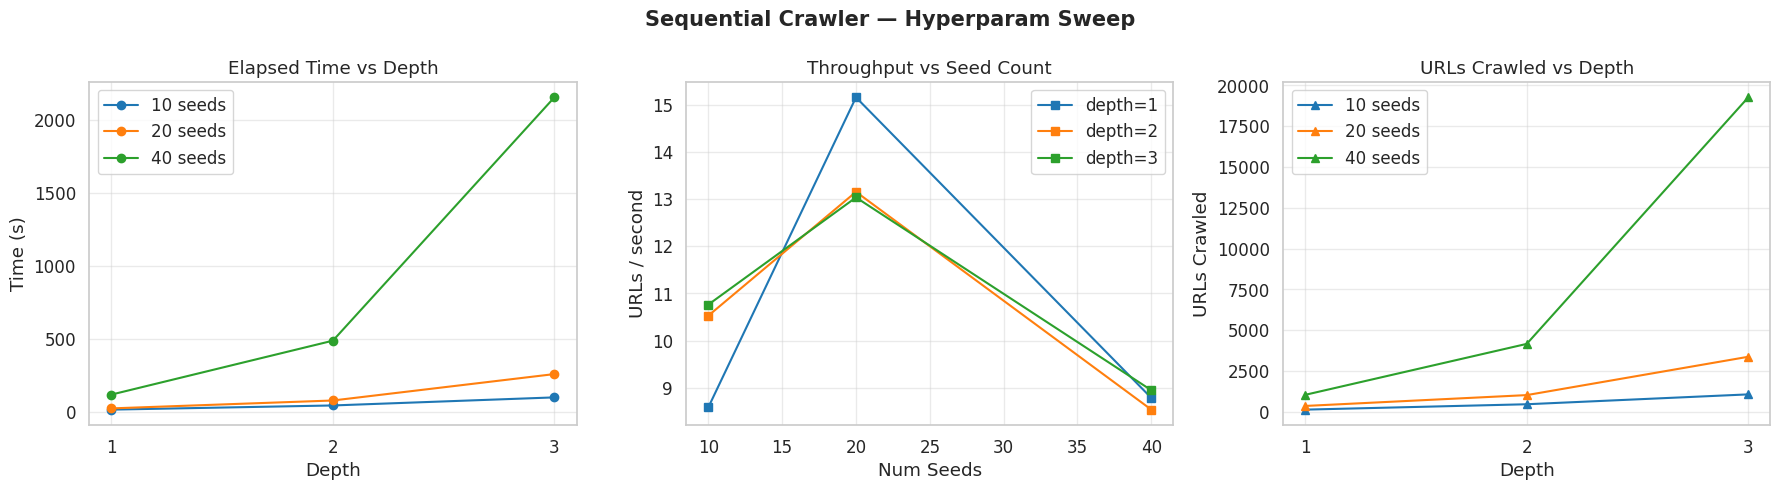

Saved → sequential_benchmark.png


In [16]:
# ── Sequential performance plots ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Sequential Crawler — Hyperparam Sweep', fontsize=15, fontweight='bold')

color = PALETTE['Sequential']

# --- Plot 1: elapsed time vs depth, grouped by num_seeds ---
ax = axes[0]
for ns in SEQ_SEED_COUNTS:
    sub = seq_df[seq_df['num_seeds'] == ns].sort_values('depth')
    ax.plot(sub['depth'], sub['elapsed_sec'], marker='o', label=f'{ns} seeds')
ax.set_title('Elapsed Time vs Depth')
ax.set_xlabel('Depth'); ax.set_ylabel('Time (s)')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(); ax.grid(True, alpha=0.4)

# --- Plot 2: throughput vs num_seeds, grouped by depth ---
ax = axes[1]
for d in SEQ_DEPTHS:
    sub = seq_df[seq_df['depth'] == d].sort_values('num_seeds')
    ax.plot(sub['num_seeds'], sub['throughput'], marker='s', label=f'depth={d}')
ax.set_title('Throughput vs Seed Count')
ax.set_xlabel('Num Seeds'); ax.set_ylabel('URLs / second')
ax.legend(); ax.grid(True, alpha=0.4)

# --- Plot 3: URLs crawled vs depth, grouped by num_seeds ---
ax = axes[2]
for ns in SEQ_SEED_COUNTS:
    sub = seq_df[seq_df['num_seeds'] == ns].sort_values('depth')
    ax.plot(sub['depth'], sub['urls_crawled'], marker='^', label=f'{ns} seeds')
ax.set_title('URLs Crawled vs Depth')
ax.set_xlabel('Depth'); ax.set_ylabel('URLs Crawled')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('sequential_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → sequential_benchmark.png')

---
## 2 · Ray Master-Worker Crawler

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  RAY MASTER-WORKER CRAWLER  (from raymasterworker.py)
# ══════════════════════════════════════════════════════════════════════════════

BATCH_SIZE_MW = 50

@ray.remote
class MWMaster:
    """Centralised coordinator: holds the global queue, visited set, and graph."""

    def __init__(self, seed_urls, max_depth, max_per_domain):
        self.max_depth      = max_depth
        self.max_per_domain = max_per_domain
        self.visited        = set()
        self.graph          = defaultdict(set)
        self.domain_counts  = defaultdict(int)
        self.queue          = []

        for url in seed_urls:
            norm = normalize_url(url)
            if norm not in self.visited:
                self.visited.add(norm)
                self.queue.append((norm, 0))

    def get_batch(self, batch_size=BATCH_SIZE_MW):
        batch = []
        while self.queue and len(batch) < batch_size:
            batch.append(self.queue.pop(0))
        return batch

    def submit_results(self, results):
        for parent, depth, children in results:
            for child in children:
                self.graph[parent].add(child)
                if depth + 1 <= self.max_depth and child not in self.visited:
                    domain = get_base_domain(child)
                    if self.domain_counts[domain] < self.max_per_domain:
                        self.visited.add(child)
                        self.domain_counts[domain] += 1
                        self.queue.append((child, depth + 1))

    def is_done(self):      return len(self.queue) == 0
    def get_graph(self):    return {k: list(v) for k, v in self.graph.items()}
    def stats(self):        return {'queue': len(self.queue),
                                    'visited': len(self.visited),
                                    'graph_nodes': len(self.graph)}


@ray.remote(max_concurrency=2)
class MWWorker:
    """Worker actor: pulls batches from Master, crawls, and pushes results back."""

    def __init__(self, worker_id):
        self.worker_id         = worker_id
        self.domain_semaphores = defaultdict(lambda: asyncio.Semaphore(3))
        self.ssl_ctx           = make_ssl_ctx()
        self.total_crawled     = 0

    async def _fetch_links(self, url, session):
        domain = urlparse(url).netloc
        async with self.domain_semaphores[domain]:
            try:
                async with session.get(
                    url, ssl=self.ssl_ctx, headers=HEADERS,
                    timeout=aiohttp.ClientTimeout(total=10)
                ) as resp:
                    if 'text/html' not in resp.headers.get('Content-Type', ''):
                        return []
                    if resp.status != 200:
                        return []
                    tree = HTMLParser(await resp.text())
                    links = [
                        a.attributes['href']
                        for a in tree.css('a[href]')
                        if 'https://' in a.attributes.get('href', '')
                    ]
                    return list({normalize_url(l) for l in links})
            except Exception:
                return []

    async def run(self, master):
        connector = aiohttp.TCPConnector(limit=100, ssl=False)
        async with aiohttp.ClientSession(headers=HEADERS, connector=connector) as session:
            empty_polls = 0
            while True:
                batch = await master.get_batch.remote(BATCH_SIZE_MW)
                if not batch:
                    empty_polls += 1
                    if empty_polls > 10:
                        break
                    await asyncio.sleep(1)
                    continue

                empty_polls = 0
                responses = await asyncio.gather(
                    *[self._fetch_links(url, session) for url, _ in batch],
                    return_exceptions=True
                )
                results = []
                for (url, depth), links in zip(batch, responses):
                    if isinstance(links, list):
                        results.append((url, depth, links))
                        self.total_crawled += 1
                    else:
                        results.append((url, depth, []))

                await master.submit_results.remote(results)

        return self.total_crawled


# ── runner ─────────────────────────────────────────────────────────────────────
def run_master_worker(seeds: list, depth: int, num_workers: int,
                      max_per_domain: int = 50) -> dict:
    master  = MWMaster.remote(seeds, depth, max_per_domain)
    workers = [MWWorker.remote(i) for i in range(num_workers)]

    t0     = time.time()
    totals = ray.get([w.run.remote(master) for w in workers])
    elapsed = time.time() - t0

    graph   = ray.get(master.get_graph.remote())
    stats   = ray.get(master.stats.remote())

    urls_crawled = stats['visited']
    total_edges  = sum(len(v) for v in graph.values())
    throughput   = urls_crawled / elapsed if elapsed > 0 else 0

    # clean up actors
    ray.kill(master)
    for w in workers:
        ray.kill(w)

    return {
        'crawler'       : 'Master-Worker',
        'num_seeds'     : len(seeds),
        'depth'         : depth,
        'num_workers'   : num_workers,
        'max_per_domain': max_per_domain,
        'elapsed_sec'   : elapsed,
        'urls_crawled'  : urls_crawled,
        'total_edges'   : total_edges,
        'throughput'    : throughput,
    }

print('MWMaster / MWWorker defined')

MWMaster / MWWorker defined


In [7]:
# ── initialise Ray once for all Ray-based sweeps ──────────────────────────────
if ray.is_initialized():
    ray.shutdown()
ray.init(ignore_reinit_error=True)
print('Ray initialised:', ray.cluster_resources())

2026-03-26 13:29:50,988	INFO worker.py:2013 -- Started a local Ray instance.


Ray initialised: {'CPU': 4.0, 'object_store_memory': 9476774707.0, 'memory': 22112474317.0, 'node:172.19.2.2': 1.0, 'node:__internal_head__': 1.0}


In [8]:
# ── Master-Worker hyperparam sweep ────────────────────────────────────────────
#
#  Grid: num_seeds × depth × num_workers

MW_SEED_COUNTS = [10, 20, 40]
MW_DEPTHS      = [1, 2]
MW_WORKERS     = [4, 8, 12]
MAX_PER_DOMAIN = 50

mw_results = []
total_runs  = len(MW_SEED_COUNTS) * len(MW_DEPTHS) * len(MW_WORKERS)
run_idx     = 0

for n_seeds, depth, n_workers in iproduct(MW_SEED_COUNTS, MW_DEPTHS, MW_WORKERS):
    run_idx += 1
    print(f'[{run_idx}/{total_runs}] Master-Worker | '
          f'seeds={n_seeds} depth={depth} workers={n_workers} …', end=' ')

    seeds  = load_seeds(n_seeds)
    result = run_master_worker(seeds, depth, n_workers,
                               max_per_domain=MAX_PER_DOMAIN)
    mw_results.append(result)

    print(f'{result["elapsed_sec"]:.1f}s  '
          f'urls={result["urls_crawled"]}  '
          f'edges={result["total_edges"]}  '
          f'({result["throughput"]:.1f} urls/s)')

mw_df = pd.DataFrame(mw_results)
print('\n── Master-Worker sweep complete ──')
mw_df.head()

[1/18] Master-Worker | seeds=10 depth=1 workers=4 … 37.7s  urls=127  edges=4611  (3.4 urls/s)
[2/18] Master-Worker | seeds=10 depth=1 workers=8 … 26.6s  urls=127  edges=4611  (4.8 urls/s)
[3/18] Master-Worker | seeds=10 depth=1 workers=12 … 27.0s  urls=127  edges=4611  (4.7 urls/s)
[4/18] Master-Worker | seeds=10 depth=2 workers=4 … 46.7s  urls=451  edges=10003  (9.7 urls/s)
[5/18] Master-Worker | seeds=10 depth=2 workers=8 … 36.6s  urls=451  edges=10868  (12.3 urls/s)
[6/18] Master-Worker | seeds=10 depth=2 workers=12 … 35.6s  urls=451  edges=11297  (12.7 urls/s)
[7/18] Master-Worker | seeds=20 depth=1 workers=4 … 38.3s  urls=353  edges=21667  (9.2 urls/s)
[8/18] Master-Worker | seeds=20 depth=1 workers=8 … 29.0s  urls=353  edges=18758  (12.2 urls/s)
[9/18] Master-Worker | seeds=20 depth=1 workers=12 … 29.2s  urls=353  edges=16880  (12.1 urls/s)
[10/18] Master-Worker | seeds=20 depth=2 workers=4 … 60.0s  urls=1033  edges=37848  (17.2 urls/s)
[11/18] Master-Worker | seeds=20 depth=2 wo

,crawler,num_seeds,depth,num_workers,max_per_domain,elapsed_sec,urls_crawled,total_edges,throughput
0,Master-Worker,10,1,4,50,37.713404,127,4611,3.367503
1,Master-Worker,10,1,8,50,26.619596,127,4611,4.770921
2,Master-Worker,10,1,12,50,26.972778,127,4611,4.708451
3,Master-Worker,10,2,4,50,46.718937,451,10003,9.653473
4,Master-Worker,10,2,8,50,36.584899,451,10868,12.327491


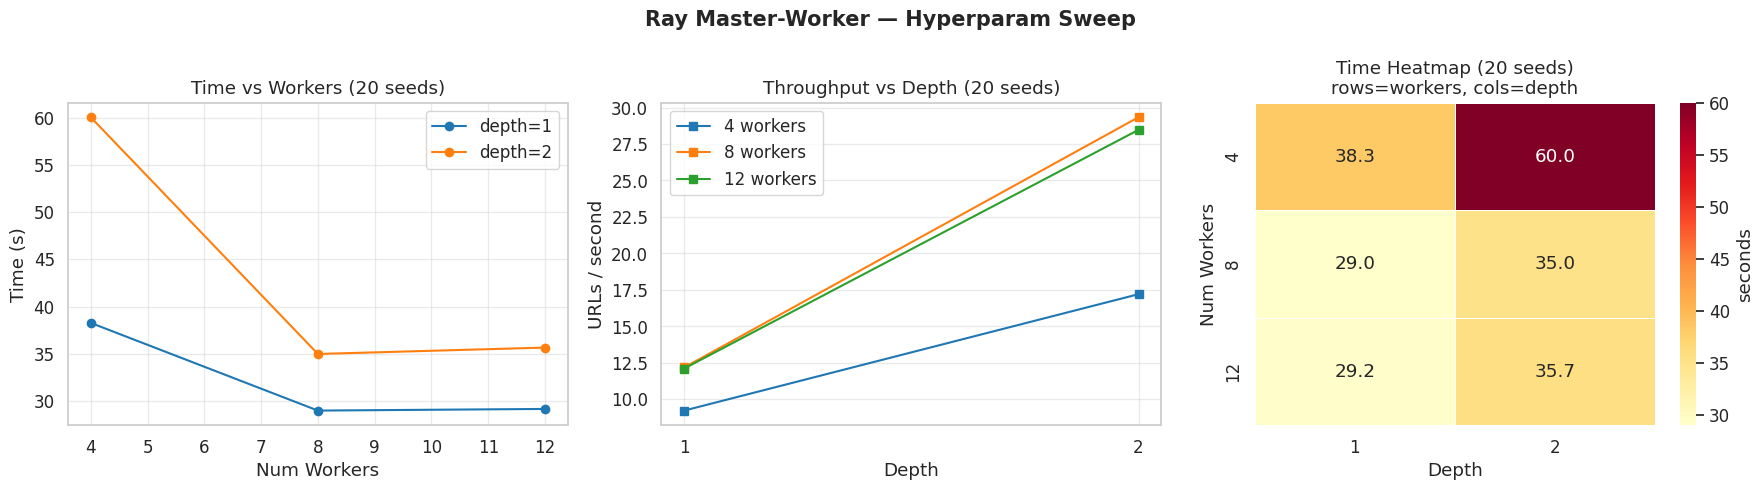

Saved → masterworker_benchmark.png


In [9]:
# ── Master-Worker performance plots ───────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ray Master-Worker — Hyperparam Sweep', fontsize=15, fontweight='bold')

# --- Plot 1: elapsed time vs num_workers, for each depth (fixed seeds=20) ---
ax = axes[0]
sub20 = mw_df[mw_df['num_seeds'] == 20]
for d in MW_DEPTHS:
    s = sub20[sub20['depth'] == d].sort_values('num_workers')
    ax.plot(s['num_workers'], s['elapsed_sec'], marker='o', label=f'depth={d}')
ax.set_title('Time vs Workers (20 seeds)')
ax.set_xlabel('Num Workers'); ax.set_ylabel('Time (s)')
ax.legend(); ax.grid(True, alpha=0.4)

# --- Plot 2: throughput vs depth, for each worker count (fixed seeds=20) ---
ax = axes[1]
for nw in MW_WORKERS:
    s = sub20[sub20['num_workers'] == nw].sort_values('depth')
    ax.plot(s['depth'], s['throughput'], marker='s', label=f'{nw} workers')
ax.set_title('Throughput vs Depth (20 seeds)')
ax.set_xlabel('Depth'); ax.set_ylabel('URLs / second')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(); ax.grid(True, alpha=0.4)

# --- Plot 3: heatmap elapsed_sec — workers × depth (fixed seeds=20) ---
ax = axes[2]
pivot = sub20.pivot_table(index='num_workers', columns='depth', values='elapsed_sec')
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'seconds'})
ax.set_title('Time Heatmap (20 seeds)\nrows=workers, cols=depth')
ax.set_xlabel('Depth'); ax.set_ylabel('Num Workers')

plt.tight_layout()
plt.savefig('masterworker_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → masterworker_benchmark.png')

---
## 3 · Ray Peer-to-Peer Crawler

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  RAY PEER-TO-PEER CRAWLER  (from raypeertopeer.py)
# ══════════════════════════════════════════════════════════════════════════════

@ray.remote
class P2PSignal:
    """Global countdown: first worker to finish starts a timer; others check it."""

    def __init__(self):
        self.stop_time = None

    def start_countdown(self, delay_seconds):
        if self.stop_time is None:
            self.stop_time = time.time() + delay_seconds

    def is_time_up(self):
        if self.stop_time is None:
            return False
        return time.time() >= self.stop_time


@ray.remote(max_concurrency=100)
class P2PWorker:
    """Fully autonomous worker: owns its slice of the URL space, 
    routes discovered links to peers via consistent hashing."""

    def __init__(self, worker_id, seed_urls, num_workers, max_per_domain):
        self.id             = worker_id
        self.num_workers    = num_workers
        self.max_per_domain = max_per_domain
        self.ssl_ctx        = make_ssl_ctx()
        self.domain_sems    = defaultdict(lambda: asyncio.Semaphore(3))

        self.visited  = set()
        self.queued   = set()
        self.frontier = [normalize_url(u) for u in seed_urls]
        self.batches  = [[] for _ in range(num_workers)]
        self.graph    = defaultdict(set)
        self.workers  = []
        self.total_visited = []

    # ------------------------------------------------------------------
    async def _fetch_links(self, url, session):
        self.total_visited.append(url)
        domain = urlparse(url).netloc
        async with self.domain_sems[domain]:
            try:
                async with session.get(
                    url, ssl=self.ssl_ctx, headers=HEADERS,
                    timeout=aiohttp.ClientTimeout(total=10)
                ) as resp:
                    if 'text/html' not in resp.headers.get('Content-Type', ''):
                        return []
                    if resp.status != 200:
                        return []
                    tree  = HTMLParser(await resp.text())
                    links = [
                        a.attributes['href']
                        for a in tree.css('a[href]')
                        if 'https://' in a.attributes.get('href', '')
                    ]
                    normed = list({normalize_url(l) for l in links})
                    self.graph[url].update(normed)
                    return normed
            except Exception:
                return []

    def _route(self, link):
        wid    = hash_id(link, self.num_workers)
        domain = get_base_domain(link)
        count  = sum(1 for l in self.batches[wid] if get_base_domain(l) == domain)
        if count < self.max_per_domain:
            self.batches[wid].append(link)

    async def receive(self, links):
        for link in links:
            if link not in self.visited and link not in self.queued:
                self.queued.add(link)
                self.frontier.append(link)

    async def run(self, workers_list, signal, max_depth, batch_size=50):
        self.workers = workers_list
        connector    = aiohttp.TCPConnector(limit=100, ssl=False)
        async with aiohttp.ClientSession(headers=HEADERS, connector=connector) as session:
            for i in range(max_depth):
                if await signal.is_time_up.remote():
                    break

                unique_frontier = list(set(self.frontier))
                if not unique_frontier:
                    await asyncio.sleep(5)
                    unique_frontier = list(set(self.frontier))

                to_crawl = []
                for link in unique_frontier:
                    if link not in self.visited:
                        self.visited.add(link)
                        to_crawl.append(link)

                self.frontier = []
                self.queued   = set()
                self.batches  = [[] for _ in range(self.num_workers)]

                all_responses = []
                for cs in range(0, len(to_crawl), batch_size):
                    if await signal.is_time_up.remote():
                        break
                    chunk = to_crawl[cs:cs + batch_size]
                    chunk_resp = await asyncio.gather(
                        *[self._fetch_links(link, session) for link in chunk],
                        return_exceptions=True
                    )
                    all_responses.extend(chunk_resp)

                links = [
                    l for sub in all_responses
                    if isinstance(sub, list)
                    for l in sub
                ]
                for link in links:
                    self._route(link)

                for wid in range(self.num_workers):
                    batch = list(set(self.batches[wid]))
                    if batch:
                        await self.workers[wid].receive.remote(batch)

                await asyncio.sleep(0.5)

        await signal.start_countdown.remote(120)
        return {k: list(v) for k, v in self.graph.items()}

    def get_total_visited(self):
        return self.total_visited


# ── runner ─────────────────────────────────────────────────────────────────────
def run_peer_to_peer(seeds: list, depth: int, num_workers: int,
                     max_per_domain: int = 50) -> dict:
    # distribute seeds by hash
    buckets = {i: [] for i in range(num_workers)}
    for seed in seeds:
        buckets[hash_id(seed, num_workers)].append(seed)

    signal  = P2PSignal.remote()
    workers = [P2PWorker.remote(i, buckets[i], num_workers, max_per_domain)
               for i in range(num_workers)]

    t0 = time.time()
    try:
        graphs = ray.get(
            [w.run.remote(workers, signal, depth) for w in workers],
            timeout=300
        )
    except ray.exceptions.GetTimeoutError:
        graphs = []
        for f in [w.run.remote(workers, signal, depth) for w in workers]:
            try:
                graphs.append(ray.get(f, timeout=1))
            except Exception:
                graphs.append({})

    elapsed = time.time() - t0

    # merge partial graphs
    merged = defaultdict(set)
    for g in graphs:
        for k, vs in g.items():
            merged[k].update(vs)

    visited_totals = ray.get([w.get_total_visited.remote() for w in workers])
    urls_crawled   = sum(len(v) for v in visited_totals)
    total_edges    = sum(len(v) for v in merged.values())
    throughput     = urls_crawled / elapsed if elapsed > 0 else 0

    ray.kill(signal)
    for w in workers:
        ray.kill(w)

    return {
        'crawler'       : 'Peer-to-Peer',
        'num_seeds'     : len(seeds),
        'depth'         : depth,
        'num_workers'   : num_workers,
        'max_per_domain': max_per_domain,
        'elapsed_sec'   : elapsed,
        'urls_crawled'  : urls_crawled,
        'total_edges'   : total_edges,
        'throughput'    : throughput,
    }

print('P2PSignal / P2PWorker defined')

P2PSignal / P2PWorker defined


In [7]:
# ── Peer-to-Peer hyperparam sweep ─────────────────────────────────────────────

P2P_SEED_COUNTS = [10, 20, 40]
P2P_DEPTHS      = [1, 2]
P2P_WORKERS     = [4, 8, 12]
MAX_PER_DOMAIN  = 50

p2p_results = []
total_runs   = len(P2P_SEED_COUNTS) * len(P2P_DEPTHS) * len(P2P_WORKERS)
run_idx      = 0

for n_seeds, depth, n_workers in iproduct(P2P_SEED_COUNTS, P2P_DEPTHS, P2P_WORKERS):
    run_idx += 1
    print(f'[{run_idx}/{total_runs}] Peer-to-Peer | '
          f'seeds={n_seeds} depth={depth} workers={n_workers} …', end=' ')

    seeds  = load_seeds(n_seeds)
    result = run_peer_to_peer(seeds, depth, n_workers,
                              max_per_domain=MAX_PER_DOMAIN)
    p2p_results.append(result)

    print(f'{result["elapsed_sec"]:.1f}s  '
          f'urls={result["urls_crawled"]}  '
          f'edges={result["total_edges"]}  '
          f'({result["throughput"]:.1f} urls/s)')

p2p_df = pd.DataFrame(p2p_results)
print('\n── P2P sweep complete ──')
p2p_df.head()

[1/18] Peer-to-Peer | seeds=10 depth=1 workers=4 … 

2026-03-26 12:52:50,312	INFO worker.py:2013 -- Started a local Ray instance.


11.2s  urls=10  edges=117  (0.9 urls/s)
[2/18] Peer-to-Peer | seeds=10 depth=1 workers=8 … 14.3s  urls=31  edges=958  (2.2 urls/s)
[3/18] Peer-to-Peer | seeds=10 depth=1 workers=12 … 14.5s  urls=72  edges=2833  (5.0 urls/s)
[4/18] Peer-to-Peer | seeds=10 depth=2 workers=4 … 20.7s  urls=92  edges=2376  (4.4 urls/s)
[5/18] Peer-to-Peer | seeds=10 depth=2 workers=8 … 52.3s  urls=333  edges=21507  (6.4 urls/s)
[6/18] Peer-to-Peer | seeds=10 depth=2 workers=12 … 29.1s  urls=415  edges=11666  (14.3 urls/s)
[7/18] Peer-to-Peer | seeds=20 depth=1 workers=4 … 13.7s  urls=25  edges=556  (1.8 urls/s)
[8/18] Peer-to-Peer | seeds=20 depth=1 workers=8 … 16.5s  urls=80  edges=2028  (4.9 urls/s)
[9/18] Peer-to-Peer | seeds=20 depth=1 workers=12 … 16.3s  urls=217  edges=8347  (13.3 urls/s)
[10/18] Peer-to-Peer | seeds=20 depth=2 workers=4 … 34.2s  urls=319  edges=10630  (9.3 urls/s)
[11/18] Peer-to-Peer | seeds=20 depth=2 workers=8 … 32.9s  urls=561  edges=17049  (17.1 urls/s)
[12/18] Peer-to-Peer | se

,crawler,num_seeds,depth,num_workers,max_per_domain,elapsed_sec,urls_crawled,total_edges,throughput
0,Peer-to-Peer,10,1,4,50,11.218686,10,117,0.891370
1,Peer-to-Peer,10,1,8,50,14.326102,31,958,2.163882
2,Peer-to-Peer,10,1,12,50,14.451507,72,2833,4.982179
3,Peer-to-Peer,10,2,4,50,20.748711,92,2376,4.434010
4,Peer-to-Peer,10,2,8,50,52.264680,333,21507,6.371416


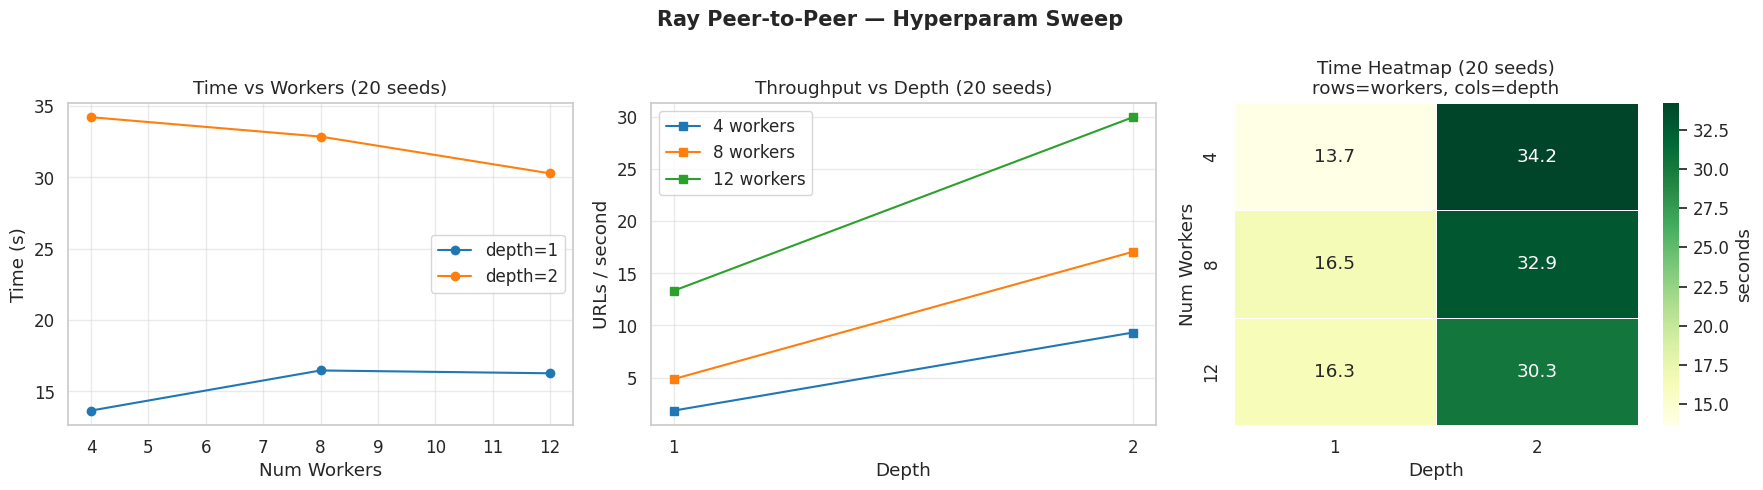

Saved → p2p_benchmark.png


In [9]:
# ── P2P performance plots ──────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ray Peer-to-Peer — Hyperparam Sweep', fontsize=15, fontweight='bold')

# --- Plot 1: elapsed time vs num_workers, for each depth (fixed seeds=20) ---
ax = axes[0]
sub20 = p2p_df[p2p_df['num_seeds'] == 20]
for d in P2P_DEPTHS:
    s = sub20[sub20['depth'] == d].sort_values('num_workers')
    ax.plot(s['num_workers'], s['elapsed_sec'], marker='o', label=f'depth={d}')
ax.set_title('Time vs Workers (20 seeds)')
ax.set_xlabel('Num Workers'); ax.set_ylabel('Time (s)')
ax.legend(); ax.grid(True, alpha=0.4)

# --- Plot 2: throughput vs depth, for each worker count ---
ax = axes[1]
for nw in P2P_WORKERS:
    s = sub20[sub20['num_workers'] == nw].sort_values('depth')
    ax.plot(s['depth'], s['throughput'], marker='s', label=f'{nw} workers')
ax.set_title('Throughput vs Depth (20 seeds)')
ax.set_xlabel('Depth'); ax.set_ylabel('URLs / second')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(); ax.grid(True, alpha=0.4)

# --- Plot 3: heatmap elapsed_sec — workers × depth ---
ax = axes[2]
pivot = sub20.pivot_table(index='num_workers', columns='depth', values='elapsed_sec')
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGn', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'seconds'})
ax.set_title('Time Heatmap (20 seeds)\nrows=workers, cols=depth')
ax.set_xlabel('Depth'); ax.set_ylabel('Num Workers')

plt.tight_layout()
plt.savefig('p2p_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → p2p_benchmark.png')